# 임차택시 대기시간 데이터 전처리

## 목적

이 노트북은 장애인콜택시 중 `임차택시` 데이터를 대상으로 대기시간 분석에 필요한 전처리 데이터를 생성하는 것을 목적으로 한다.

임차택시는 운영상 바로콜만 가능한 것으로 확인되었지만, 원자료에는 `이용목적`에 `예약`이 포함된 건과 접수 후 승차까지 시간이 매우 긴 건이 일부 존재한다. 이러한 건을 그대로 포함하면 바로콜 대기시간이 과대 해석될 수 있으므로, 본 노트북에서는 바로콜 분석 대상과 예외 확인 대상을 분리한다.

## 주요 전처리 내용

- 임차택시 데이터만 분리
- 서울 내부 또는 서울 연계 이동만 유지
- `서울 외→서울 외` 이동 제외
- 핵심 대기시간 4구간 생성
  - `접수→배차`
  - `접수→승차`
  - `접수→취소`
  - `배차→취소`
- 보조 확인용 대기시간 생성
  - `배차→승차`
- 예약 목적 여부 생성
- 접수일자와 승차일자의 날짜 차이 생성
- 임차택시 바로콜 및 예외 여부 생성
- 취소 분석 유형 생성
- 분석용 전처리 결과 저장

## 분석 기준

- 분석 대상 차량: `임차택시`
- 기준 시점: `접수일시`
- 이동 범위: `서울→서울`, `서울→서울 외`, `서울 외→서울`
- 제외 범위: `서울 외→서울 외`
- 바로콜 기준: 예약 목적이 아니고 `접수→승차` 시간이 0~250분인 건
- 예외 기준:
  - `이용목적`에 `예약`이 포함된 건
  - 예약 목적은 아니지만 `접수→승차` 시간이 250분을 초과하는 건
- 취소 본 분석 기준: 예약 목적이 아닌 바로콜 취소 건

## 산출물

최종 전처리 결과는 다음 파일로 저장한다.

`data/processed/임차택시_대기시간_전처리.csv`

이 파일은 이후 임차택시 대기시간 분석 노트북에서 다시 불러와 사용한다.

In [109]:
import platform
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

boarding_path = PROCESSED_DIR / "서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv"
print(boarding_path)

df = pd.read_csv(boarding_path)
print(f"전체 행 수: {len(df):,}")
display(df.head())

/Users/blaumonde/calltaxi-DA/data/processed/서울시설공단_장애인콜택시 탑승내역_정제_20251231.csv
전체 행 수: 1,722,490


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


## 01. 데이터 확인

### 날짜·시간 컬럼 변환
대기시간 계산에 필요한 일시 컬럼을 datetime으로 변환한다.

In [110]:
datetime_cols = [
    "접수일시",
    "예정일시",
    "배차일시",
    "승차일시",
    "하차일시",
    "취소일시",
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[datetime_cols].dtypes

접수일시    datetime64[us]
예정일시    datetime64[us]
배차일시    datetime64[us]
승차일시    datetime64[us]
하차일시    datetime64[us]
취소일시    datetime64[us]
dtype: object

In [111]:
print(df['이용목적'].unique())
print(df['차량구분'].unique())
print(df['차량구분'].isna().sum())

<StringArray>
[     '기타',      '귀가',      '치료',      '종교',   '통학/출근',    '예약기타',    '예약치료',
    '예약광역',      '재활',    '예약재활',    '예약귀가',    '치료광역', '예약통학/출근',      '쇼핑',
    '공항티켓',      '업무',    '심야예약']
Length: 17, dtype: str
<StringArray>
['특장차', '임차택시']
Length: 2, dtype: str
0


### 임차택시 전체 `328881건`

In [112]:
df[df['차량구분'] == '임차택시'].head()

,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
79,2025-01-01 05:56:10.000,2025-01-01 05:57:00,2025-01-01 07:55:00,2025-01-01 08:17:00,2025-01-01 08:29:00,NaT,강동구,상일동,강동구,명일제2동,치료,1500.0,2000,임차택시,신장
83,2025-01-01 03:55:00.983,2025-01-01 06:00:00,2025-01-01 07:05:00,2025-01-01 07:15:00,2025-01-01 07:28:00,NaT,성북구,삼선동,성북구,길음제2동,치료,1500.0,4000,임차택시,뇌병
125,2025-01-01 06:27:42.000,2025-01-01 07:00:00,2025-01-01 08:25:00,2025-01-01 08:30:00,2025-01-01 09:12:00,NaT,서초구,방배3동,노원구,상계6.7동,기타,4200.0,29000,임차택시,지체
132,2025-01-01 07:15:29.733,2025-01-01 07:15:00,2025-01-01 08:37:00,2025-01-01 08:45:00,2025-01-01 09:00:00,NaT,강동구,암사제3동,강동구,길동,기타,1500.0,4000,임차택시,신장
206,2025-01-01 08:45:22.857,2025-01-01 08:45:00,2025-01-01 09:25:00,2025-01-01 09:45:00,2025-01-01 10:12:00,NaT,강동구,강일동,하남시,신장1동,기타,1500.0,5000,임차택시,신장


### 임차택시 전일 접수 장시간 대기 데이터 확인
차량구분이 임차택시인 데이터 중, 접수일시의 날짜가 승차일시보다 하루 전이고 실제 접수부터 승차까지의 시간 차이가 4시간 이상인 건을 확인한다.

In [113]:
rental_taxi_prev_day_4h_plus = df[
    (df["차량구분"] == "임차택시")
    & df["접수일시"].notna()
    & df["승차일시"].notna()
    & ((df["승차일시"].dt.normalize() - df["접수일시"].dt.normalize()).dt.days == 1)
    & ((df["승차일시"] - df["접수일시"]).dt.total_seconds() >= 4 * 60 * 60)
].copy()

print(
    "임차택시 중 접수일시 날짜가 승차일시보다 하루 전이고 "
    f"시간 차이가 4시간 이상인 건수: {len(rental_taxi_prev_day_4h_plus):,}건"
)

display(
    rental_taxi_prev_day_4h_plus[
        ["차량구분", "접수일시", "승차일시", "예정일시", "배차일시", "하차일시", "취소일시"]
    ].sort_values(["접수일시", "승차일시"]).head(10)
)

임차택시 중 접수일시 날짜가 승차일시보다 하루 전이고 시간 차이가 4시간 이상인 건수: 6,841건


,차량구분,접수일시,승차일시,예정일시,배차일시,하차일시,취소일시
335,임차택시,2024-12-31 10:32:30.827,2025-01-01 10:15:35.897,2025-01-01 10:00:00,2025-01-01 10:02:56.640,2025-01-01 10:50:10.050,NaT
2762,임차택시,2025-01-01 10:00:20.967,2025-01-02 10:08:51.257,2025-01-02 10:00:00,2025-01-02 10:02:00.223,2025-01-02 10:25:22.290,NaT
2778,임차택시,2025-01-01 10:02:26.123,2025-01-02 10:12:44.963,2025-01-02 10:00:00,2025-01-02 10:01:35.503,2025-01-02 10:25:54.167,NaT
2779,임차택시,2025-01-01 10:03:50.000,2025-01-02 10:22:26.170,2025-01-02 10:00:00,2025-01-02 10:06:07.693,2025-01-02 10:44:17.780,NaT
2783,임차택시,2025-01-01 10:08:03.610,2025-01-02 10:34:12.073,2025-01-02 10:00:00,2025-01-02 10:09:05.743,2025-01-02 10:47:06.623,NaT
2786,임차택시,2025-01-01 10:10:53.847,2025-01-02 10:30:15.647,2025-01-02 10:00:00,2025-01-02 10:05:38.740,2025-01-02 10:45:37.310,NaT
2788,임차택시,2025-01-01 10:15:26.000,2025-01-02 10:21:43.250,2025-01-02 10:00:00,2025-01-02 10:02:12.770,2025-01-02 10:31:25.650,NaT
2790,임차택시,2025-01-01 10:17:30.000,2025-01-02 10:11:33.447,2025-01-02 10:00:00,2025-01-02 10:03:18.130,2025-01-02 11:07:17.490,NaT
2791,임차택시,2025-01-01 10:17:55.000,2025-01-02 10:12:06.527,2025-01-02 10:00:00,2025-01-02 10:02:38.050,2025-01-02 11:03:56.183,NaT
2792,임차택시,2025-01-01 10:18:59.040,2025-01-02 10:14:13.423,2025-01-02 10:00:00,2025-01-02 10:01:45.970,2025-01-02 10:35:41.497,NaT


### 임차택시 예약 목적 데이터 확인 `6939건`
차량구분이 임차택시인 데이터 중, 이용목적에 예약이라는 단어가 포함된 건이 있는지 확인한다.

In [114]:
rental_taxi_reservation = df[
    (df["차량구분"] == "임차택시")
    & df["이용목적"].notna()
    & df["이용목적"].astype(str).str.contains("예약", na=False)
].copy()

print(f"임차택시 중 이용목적에 '예약'이 포함된 건수: {len(rental_taxi_reservation):,}건")

display(
    rental_taxi_reservation[
        ["차량구분", "이용목적", "접수일시", "예정일시", "배차일시", "승차일시", "하차일시", "취소일시"]
    ].head(20)
)

임차택시 중 이용목적에 '예약'이 포함된 건수: 6,939건


,차량구분,이용목적,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시
335,임차택시,예약기타,2024-12-31 10:32:30.827,2025-01-01 10:00:00,2025-01-01 10:02:56.640,2025-01-01 10:15:35.897,2025-01-01 10:50:10.050,NaT
2762,임차택시,예약기타,2025-01-01 10:00:20.967,2025-01-02 10:00:00,2025-01-02 10:02:00.223,2025-01-02 10:08:51.257,2025-01-02 10:25:22.290,NaT
2778,임차택시,예약기타,2025-01-01 10:02:26.123,2025-01-02 10:00:00,2025-01-02 10:01:35.503,2025-01-02 10:12:44.963,2025-01-02 10:25:54.167,NaT
2779,임차택시,예약기타,2025-01-01 10:03:50.000,2025-01-02 10:00:00,2025-01-02 10:06:07.693,2025-01-02 10:22:26.170,2025-01-02 10:44:17.780,NaT
2783,임차택시,예약기타,2025-01-01 10:08:03.610,2025-01-02 10:00:00,2025-01-02 10:09:05.743,2025-01-02 10:34:12.073,2025-01-02 10:47:06.623,NaT
2786,임차택시,예약기타,2025-01-01 10:10:53.847,2025-01-02 10:00:00,2025-01-02 10:05:38.740,2025-01-02 10:30:15.647,2025-01-02 10:45:37.310,NaT
2788,임차택시,예약재활,2025-01-01 10:15:26.000,2025-01-02 10:00:00,2025-01-02 10:02:12.770,2025-01-02 10:21:43.250,2025-01-02 10:31:25.650,NaT
2790,임차택시,예약기타,2025-01-01 10:17:30.000,2025-01-02 10:00:00,2025-01-02 10:03:18.130,2025-01-02 10:11:33.447,2025-01-02 11:07:17.490,NaT
2791,임차택시,예약기타,2025-01-01 10:17:55.000,2025-01-02 10:00:00,2025-01-02 10:02:38.050,2025-01-02 10:12:06.527,2025-01-02 11:03:56.183,NaT
2792,임차택시,예약기타,2025-01-01 10:18:59.040,2025-01-02 10:00:00,2025-01-02 10:01:45.970,2025-01-02 10:14:13.423,2025-01-02 10:35:41.497,NaT


### 임차택시 예약 목적 전일 접수 여부 확인
차량구분이 임차택시이고 이용목적에 예약이 포함된 데이터 중, YYMMDD 기준으로 접수일시의 날짜가 승차일시보다 하루 앞선 건이 있는지 확인한다.

In [115]:
rental_taxi_reservation_prev_day = df[
    (df["차량구분"] == "임차택시")
    & df["이용목적"].notna()
    & df["이용목적"].astype(str).str.contains("예약", na=False)
    & df["접수일시"].notna()
    & df["승차일시"].notna()
    & ((df["승차일시"].dt.normalize() - df["접수일시"].dt.normalize()).dt.days == 1)
].copy()

print(
    "임차택시 예약 목적 중 접수일시 날짜가 승차일시보다 하루 앞선 건수: "
    f"{len(rental_taxi_reservation_prev_day):,}건"
)

display(
    rental_taxi_reservation_prev_day[
        ["차량구분", "이용목적", "접수일시", "승차일시", "예정일시", "배차일시", "하차일시", "취소일시"]
    ].sort_values(["접수일시", "승차일시"]).head(10)
)

임차택시 예약 목적 중 접수일시 날짜가 승차일시보다 하루 앞선 건수: 6,831건


,차량구분,이용목적,접수일시,승차일시,예정일시,배차일시,하차일시,취소일시
335,임차택시,예약기타,2024-12-31 10:32:30.827,2025-01-01 10:15:35.897,2025-01-01 10:00:00,2025-01-01 10:02:56.640,2025-01-01 10:50:10.050,NaT
2762,임차택시,예약기타,2025-01-01 10:00:20.967,2025-01-02 10:08:51.257,2025-01-02 10:00:00,2025-01-02 10:02:00.223,2025-01-02 10:25:22.290,NaT
2778,임차택시,예약기타,2025-01-01 10:02:26.123,2025-01-02 10:12:44.963,2025-01-02 10:00:00,2025-01-02 10:01:35.503,2025-01-02 10:25:54.167,NaT
2779,임차택시,예약기타,2025-01-01 10:03:50.000,2025-01-02 10:22:26.170,2025-01-02 10:00:00,2025-01-02 10:06:07.693,2025-01-02 10:44:17.780,NaT
2783,임차택시,예약기타,2025-01-01 10:08:03.610,2025-01-02 10:34:12.073,2025-01-02 10:00:00,2025-01-02 10:09:05.743,2025-01-02 10:47:06.623,NaT
2786,임차택시,예약기타,2025-01-01 10:10:53.847,2025-01-02 10:30:15.647,2025-01-02 10:00:00,2025-01-02 10:05:38.740,2025-01-02 10:45:37.310,NaT
2788,임차택시,예약재활,2025-01-01 10:15:26.000,2025-01-02 10:21:43.250,2025-01-02 10:00:00,2025-01-02 10:02:12.770,2025-01-02 10:31:25.650,NaT
2790,임차택시,예약기타,2025-01-01 10:17:30.000,2025-01-02 10:11:33.447,2025-01-02 10:00:00,2025-01-02 10:03:18.130,2025-01-02 11:07:17.490,NaT
2791,임차택시,예약기타,2025-01-01 10:17:55.000,2025-01-02 10:12:06.527,2025-01-02 10:00:00,2025-01-02 10:02:38.050,2025-01-02 11:03:56.183,NaT
2792,임차택시,예약기타,2025-01-01 10:18:59.040,2025-01-02 10:14:13.423,2025-01-02 10:00:00,2025-01-02 10:01:45.970,2025-01-02 10:35:41.497,NaT


### 임차택시 당일접수 예약 `13건`

In [116]:
# 임차택시 예약 목적 중 접수일시 날짜가 승차일시보다 하루 앞서지 않은 나머지 데이터 확인
rental_taxi_reservation_not_prev_day = df[
    (df["차량구분"] == "임차택시")
    & df["이용목적"].notna()
    & df["이용목적"].astype(str).str.contains("예약", na=False)
    & df["접수일시"].notna()
    & df["승차일시"].notna()
    & ((df["승차일시"].dt.normalize() - df["접수일시"].dt.normalize()).dt.days != 1)
].copy()

print(
    "임차택시 예약 목적 중 접수일시 날짜가 승차일시보다 하루 앞서지 않은 건수: "
    f"{len(rental_taxi_reservation_not_prev_day):,}건"
)

display(
    rental_taxi_reservation_not_prev_day[
        ["차량구분", "이용목적", "접수일시", "승차일시", "예정일시", "배차일시", "하차일시", "취소일시"]
    ].sort_values(["접수일시", "승차일시"])
)

임차택시 예약 목적 중 접수일시 날짜가 승차일시보다 하루 앞서지 않은 건수: 13건


,차량구분,이용목적,접수일시,승차일시,예정일시,배차일시,하차일시,취소일시
440235,임차택시,예약치료,2025-04-10 07:11:41.000,2025-04-10 07:37:26.180,2025-04-10 07:12:00,2025-04-10 07:15:40.510,2025-04-10 08:07:03.583,NaT
446695,임차택시,예약기타,2025-04-11 08:01:46.000,2025-04-11 08:56:39.613,2025-04-11 08:02:00,2025-04-11 08:43:32.927,2025-04-11 09:14:49.420,NaT
475871,임차택시,예약치료,2025-04-17 10:03:20.000,2025-04-17 10:28:17.210,2025-04-17 10:04:00,2025-04-17 10:12:43.650,2025-04-17 10:45:48.163,NaT
517267,임차택시,예약치료,2025-04-25 10:03:33.000,2025-04-25 10:36:48.680,2025-04-25 10:04:00,2025-04-25 10:16:24.313,2025-04-25 10:50:46.410,NaT
715292,임차택시,예약기타,2025-06-09 10:02:08.000,2025-06-09 10:31:39.640,2025-06-09 10:03:00,2025-06-09 10:11:17.963,2025-06-09 10:39:00.917,NaT
832449,임차택시,예약기타,2025-07-02 11:08:06.000,2025-07-02 11:22:10.297,2025-07-02 11:09:00,2025-07-02 11:12:10.053,2025-07-02 11:33:49.710,NaT
832451,임차택시,예약기타,2025-07-02 11:08:24.000,2025-07-02 11:23:35.657,2025-07-02 11:09:00,2025-07-02 11:10:14.430,2025-07-02 11:46:54.597,NaT
946872,임차택시,예약기타,2025-07-23 14:44:36.733,2025-07-23 15:06:47.297,2025-07-24 14:44:00,2025-07-23 14:48:01.800,2025-07-23 15:34:44.937,NaT
1242818,임차택시,예약치료,2025-09-22 16:32:29.000,2025-09-22 18:03:45.497,2025-09-22 16:33:00,2025-09-22 17:35:14.580,2025-09-22 18:11:45.890,NaT
1314650,임차택시,예약기타,2025-10-10 11:23:44.000,2025-10-10 11:56:40.690,2025-10-10 11:24:00,2025-10-10 11:35:03.863,2025-10-10 12:28:18.407,NaT


### 접수일시와 취소일시 날짜 불일치 장시간 데이터 확인

접수일시와 취소일시의 `YYMMDD` 기준 날짜가 서로 다르고, 실제 접수부터 취소까지의 시간 차이가 4시간 이상인 데이터를 확인한다.

In [117]:
request_cancel_diff_day_4h_plus = df[
    df["접수일시"].notna()
    & df["취소일시"].notna()
    & (df["접수일시"].dt.normalize() != df["취소일시"].dt.normalize())
    & ((df["취소일시"] - df["접수일시"]).dt.total_seconds().abs() >= 4 * 60 * 60)
].copy()

print(
    "접수일시와 취소일시의 날짜가 다르고 실제 시간 차이가 4시간 이상인 건수: "
    f"{len(request_cancel_diff_day_4h_plus):,}건"
)

display(
    request_cancel_diff_day_4h_plus[
        ["접수일시", "취소일시", "차량구분", "이용목적", "예정일시", "배차일시", "승차일시", "하차일시"]
    ].sort_values(["접수일시", "취소일시"]).head(10)
)

접수일시와 취소일시의 날짜가 다르고 실제 시간 차이가 4시간 이상인 건수: 6,060건


,접수일시,취소일시,차량구분,이용목적,예정일시,배차일시,승차일시,하차일시
109,2024-12-31 07:03:54.000,2025-01-01 08:30:21,특장차,예약치료,2025-01-01 07:00:00,NaT,NaT,NaT
115,2024-12-31 09:14:00.050,2025-01-01 05:11:16,특장차,예약기타,2025-01-01 07:00:00,NaT,NaT,NaT
330,2024-12-31 10:01:04.600,2025-01-01 07:44:36,특장차,예약기타,2025-01-01 10:00:00,NaT,NaT,NaT
336,2024-12-31 11:05:21.900,2025-01-01 09:00:56,특장차,예약기타,2025-01-01 10:00:00,NaT,NaT,NaT
343,2024-12-31 15:39:03.770,2025-01-01 09:02:56,특장차,예약기타,2025-01-01 10:00:00,NaT,NaT,NaT
163,2024-12-31 17:14:28.757,2025-01-01 08:12:55,특장차,예약기타,2025-01-01 08:00:00,NaT,NaT,NaT
164,2024-12-31 17:19:39.000,2025-01-01 08:23:09,특장차,예약기타,2025-01-01 08:00:00,NaT,NaT,NaT
117,2024-12-31 20:26:17.953,2025-01-01 07:39:14,특장차,예약기타,2025-01-01 07:00:00,NaT,NaT,NaT
1564,2025-01-01 07:00:20.717,2025-01-02 06:01:12,특장차,예약기타,2025-01-02 07:00:00,NaT,NaT,NaT
1590,2025-01-01 07:01:19.093,2025-01-02 06:46:23,특장차,예약기타,2025-01-02 07:00:00,NaT,NaT,NaT


## 임차택시 예약 목적 나머지 데이터 취소 여부 확인

임차택시 예약 목적 데이터 중 접수일시 날짜가 승차일시보다 하루 앞서지 않은 나머지 95건에 대해, 승차일시는 없고 취소일시가 있는 건을 확인한다.   

In [118]:
rental_taxi_reservation_cancel_only = rental_taxi_reservation_not_prev_day[
    rental_taxi_reservation_not_prev_day["승차일시"].isna()
    & rental_taxi_reservation_not_prev_day["취소일시"].notna()
].copy()

print(
    "임차택시 예약 목적 나머지 데이터 중 승차일시가 없고 취소일시가 있는 건수: "
    f"{len(rental_taxi_reservation_cancel_only):,}건"
)

display(
    rental_taxi_reservation_cancel_only[
        ["차량구분", "이용목적", "접수일시", "승차일시", "취소일시", "예정일시", "배차일시", "하차일시"]
    ].sort_values(["접수일시", "취소일시"]).head(50)
)

임차택시 예약 목적 나머지 데이터 중 승차일시가 없고 취소일시가 있는 건수: 0건


,차량구분,이용목적,접수일시,승차일시,취소일시,예정일시,배차일시,하차일시


### 임차택시
- 임차택시 전체: 328,881건
- 임차택시 중 이용목적에 예약 포함: 6,939건
- 그중 승차일시가 있는 건: 6,844건
- 그중 접수일자가 승차일자보다 하루 앞선 건: 6,831건
- 접수일자와 승차일자가 같은 예약 건: 13건
- 나머지 95건은 승차일시가 없고 취소일시가 있는 건

- 6,939건 = 승차 있는 예약 6,844건 + 취소된 예약 95건
- 6,844건 = 전일접수 예약 6,831건 + 당일접수 예약 13건

## 임차택시 비예약 목적 접수-승차 시간 분포 확인

임차택시 중 이용목적에 `예약`이 포함되지 않은 건을 실제 바로콜에 가장 가까운 기준 집단으로 보고, 해당 집단의 `접수→승차` 소요시간 분포를 확인한다.

확인 지표는 중앙값, 75분위수, 90분위수, 95분위수, 99분위수, 최대값이다.

In [119]:
# 임차택시 중 예약 목적이 아닌 바로콜 기준 집단
rental_taxi_non_reservation = df[
    (df["차량구분"] == "임차택시")
    & df["이용목적"].notna()
    & ~df["이용목적"].astype(str).str.contains("예약", na=False)
    & df["접수일시"].notna()
    & df["승차일시"].notna()
].copy()

# 접수→승차 소요시간(분)
rental_taxi_non_reservation["접수_승차_분"] = (
    rental_taxi_non_reservation["승차일시"] - rental_taxi_non_reservation["접수일시"]
).dt.total_seconds() / 60

# 음수 소요시간은 이상치로 제외
rental_taxi_non_reservation_valid = rental_taxi_non_reservation[
    rental_taxi_non_reservation["접수_승차_분"] >= 0
].copy()

summary = rental_taxi_non_reservation_valid["접수_승차_분"].agg(
    건수="count",
    중앙값="median",
    최대값="max",
)

quantiles = rental_taxi_non_reservation_valid["접수_승차_분"].quantile(
    [0.75, 0.90, 0.95, 0.99]
)

distribution_summary = pd.DataFrame({
    "지표": ["건수", "중앙값", "75분위수", "90분위수", "95분위수", "99분위수", "최대값"],
    "접수_승차_분": [
        summary["건수"],
        summary["중앙값"],
        quantiles.loc[0.75],
        quantiles.loc[0.90],
        quantiles.loc[0.95],
        quantiles.loc[0.99],
        summary["최대값"],
    ],
})

display(distribution_summary)

,지표,접수_승차_분
0,건수,305758.000000
1,중앙값,28.516108
2,75분위수,50.285575
3,90분위수,87.364887
4,95분위수,145.073174
5,99분위수,174.802182
6,최대값,1667.213833


## 02. 데이터 전처리

### 1. 임차택시 데이터 분리
전체 데이터에서 임차택시만 분리한다.

In [120]:
df_rental = df[df["차량구분"] == "임차택시"].copy()

rental_summary = pd.DataFrame({
    "항목": [
        "임차택시 전체 건수",
        "승차일시 존재 건수",
        "취소일시 존재 건수",
        "승차 완료 건수",
        "취소 건수",
    ],
    "건수": [
        len(df_rental),
        df_rental["승차일시"].notna().sum(),
        df_rental["취소일시"].notna().sum(),
        df_rental["승차일시"].notna().sum(),
        df_rental["취소일시"].notna().sum(),
    ],
})

display(rental_summary)

,항목,건수
0,임차택시 전체 건수,328881
1,승차일시 존재 건수,312602
2,취소일시 존재 건수,16279
3,승차 완료 건수,312602
4,취소 건수,16279


### 2. 서울 외부 간 이동 데이터 제거

임차택시 데이터에서 출발구와 목적구가 모두 서울 25개 자치구에 포함되지 않는 서울 외 → 서울 외 이동 건을 제거한다.

In [121]:
seoul_gu = [
    "강남구", "강동구", "강북구", "강서구", "관악구",
    "광진구", "구로구", "금천구", "노원구", "도봉구",
    "동대문구", "동작구", "마포구", "서대문구", "서초구",
    "성동구", "성북구", "송파구", "양천구", "영등포구",
    "용산구", "은평구", "종로구", "중구", "중랑구",
]

rental_outside_to_outside = df_rental[
    ~df_rental["출발구"].isin(seoul_gu)
    & ~df_rental["목적구"].isin(seoul_gu)
].copy()

print(f"임차택시 중 서울 외 → 서울 외 건수: {len(rental_outside_to_outside):,}건")

display(
    rental_outside_to_outside[
        ["출발구", "목적구", "차량구분", "이용목적", "접수일시", "승차일시", "취소일시"]
    ].head(50)
)

임차택시 중 서울 외 → 서울 외 건수: 6건


,출발구,목적구,차량구분,이용목적,접수일시,승차일시,취소일시
762919,하남시,성남시분당구,임차택시,기타,2025-06-18 11:14:44,2025-06-18 11:38:34.067,NaT
782871,하남시,성남시분당구,임차택시,기타,2025-06-22 15:09:50,NaT,2025-06-22 15:29:58
782909,의정부시,고양시덕양구,임차택시,귀가,2025-06-22 15:19:06,2025-06-22 16:15:33.500,NaT
1247745,구리시,남양주시,임차택시,기타,2025-09-23 14:27:55,2025-09-23 14:50:04.973,NaT
1461588,구리시,남양주시,임차택시,기타,2025-11-08 13:38:03,2025-11-08 13:56:03.583,NaT
1533950,구리시,남양주시,임차택시,기타,2025-11-23 14:34:40,2025-11-23 14:50:06.543,NaT


In [122]:
df_rental = df_rental[
    df_rental["출발구"].isin(seoul_gu)
    | df_rental["목적구"].isin(seoul_gu)
].copy()

print(f"서울 외 → 서울 외 제거 후 임차택시 건수: {len(df_rental):,}건")

서울 외 → 서울 외 제거 후 임차택시 건수: 328,875건


### 5. 대기시간 4구간 생성

임차택시 데이터에서 핵심 대기시간 4구간과 보조 확인용 구간을 분 단위로 계산한다.

핵심 분석 컬럼:

- `접수_배차_분`
- `접수_승차_분`
- `접수_취소_분`
- `배차_취소_분`

보조 확인 컬럼:

- `배차_승차_분`

각 대기시간 컬럼의 역할은 다음과 같다.

| 컬럼 | 의미 | 전처리/분석 역할 |
|---|---|---|
| `접수_배차_분` | 접수 후 차량이 배정되기까지 걸린 시간 | 핵심 지표. 배차 지연 또는 차량 공급 부족 가능성 확인 |
| `접수_승차_분` | 접수 후 실제 승차까지 걸린 전체 시간 | 핵심 지표. 이용자가 체감하는 전체 승차 대기시간 확인 및 임차택시 바로콜 정상/경계/예외 분리 기준으로 사용 |
| `접수_취소_분` | 접수 후 취소까지 걸린 시간 | 핵심 지표. 접수 후 어느 정도 시간이 지나 취소가 발생하는지 확인 |
| `배차_취소_분` | 차량 배정 후 취소까지 걸린 시간 | 핵심 지표. 배차 이후에도 취소되는 건의 시간 흐름 확인 |
| `배차_승차_분` | 차량 배정 후 실제 승차까지 걸린 시간 | 보조 지표. `접수→승차` 시간이 길어진 원인을 추가로 분해할 때 확인 |

전처리 단계에서는 핵심 4구간인 `접수_배차_분`, `접수_승차_분`, `접수_취소_분`, `배차_취소_분`을 반드시 생성한다.

`배차_승차_분`은 핵심 지표에서는 제외하지만, `접수→승차` 시간이 길어진 원인을 배차 이후 단계까지 확인할 때 보조적으로 사용한다.

각 구간별 유효 표본 수도 함께 확인한다.

In [123]:
# 대기시간 컬럼 생성
df_rental["접수_배차_분"] = (
    df_rental["배차일시"] - df_rental["접수일시"]
).dt.total_seconds() / 60

df_rental["접수_승차_분"] = (
    df_rental["승차일시"] - df_rental["접수일시"]
).dt.total_seconds() / 60

df_rental["접수_취소_분"] = (
    df_rental["취소일시"] - df_rental["접수일시"]
).dt.total_seconds() / 60

df_rental["배차_취소_분"] = (
    df_rental["취소일시"] - df_rental["배차일시"]
).dt.total_seconds() / 60

df_rental["배차_승차_분"] = (
    df_rental["승차일시"] - df_rental["배차일시"]
).dt.total_seconds() / 60

In [124]:
# 유효 표본 수 확인
wait_valid_sample_summary = pd.DataFrame({
    "대기시간구간": [
        "접수→배차",
        "접수→승차",
        "접수→취소",
        "배차→취소",
        "배차→승차",
    ],
    "분석역할": [
        "핵심",
        "핵심",
        "핵심",
        "핵심",
        "보조",
    ],
    "컬럼명": [
        "접수_배차_분",
        "접수_승차_분",
        "접수_취소_분",
        "배차_취소_분",
        "배차_승차_분",
    ],
    "유효건수": [
        df_rental["접수_배차_분"].notna().sum(),
        df_rental["접수_승차_분"].notna().sum(),
        df_rental["접수_취소_분"].notna().sum(),
        df_rental["배차_취소_분"].notna().sum(),
        df_rental["배차_승차_분"].notna().sum(),
    ],
    "결측건수": [
        df_rental["접수_배차_분"].isna().sum(),
        df_rental["접수_승차_분"].isna().sum(),
        df_rental["접수_취소_분"].isna().sum(),
        df_rental["배차_취소_분"].isna().sum(),
        df_rental["배차_승차_분"].isna().sum(),
    ],
})

display(wait_valid_sample_summary)

,대기시간구간,분석역할,컬럼명,유효건수,결측건수
0,접수→배차,핵심,접수_배차_분,328859,16
1,접수→승차,핵심,접수_승차_분,312597,16278
2,접수→취소,핵심,접수_취소_분,16278,312597
3,배차→취소,핵심,배차_취소_분,16262,312613
4,배차→승차,보조,배차_승차_분,312597,16278


### 배차일시가 없는 취소 건 확인

`접수→취소` 시간은 계산되지만 `배차→취소` 시간이 계산되지 않는 건은 `취소일시`는 있으나 `배차일시`가 없는 건이다.

즉, 이 건들은 배차 후 취소가 아니라 **배차 전 취소**이거나, 배차일시가 기록되지 않은 취소 건으로 볼 수 있다.

현재 유효 표본 수 기준으로는 다음 관계가 확인된다.

- `접수→취소` 유효건수: 16,278건
- `배차→취소` 유효건수: 16,262건
- 차이: 16건
- 배차 후 취소 비율 = 16,262 / 16,278 = 약 99.9%

따라서 이 16건은 취소 분석에서 별도로 확인한다.

In [125]:
cancel_without_dispatch = df_rental[
    df_rental["취소일시"].notna()
    & df_rental["배차일시"].isna()
].copy()

print(f"배차일시가 없는 취소 건수: {len(cancel_without_dispatch):,}건")

display(
    cancel_without_dispatch[
        [
            "접수일시",
            "배차일시",
            "승차일시",
            "취소일시",
            "차량구분",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
            "접수_취소_분",
            "배차_취소_분",
        ]
    ].head(20)
)

배차일시가 없는 취소 건수: 16건


,접수일시,배차일시,승차일시,취소일시,차량구분,이용목적,출발구,출발동,목적구,목적동,접수_취소_분,배차_취소_분
137054,2025-02-04 12:00:22.730,NaT,NaT,2025-02-04 12:02:19,임차택시,기타,마포구,상암동,송파구,가락1동,1.937833,NaN
367347,2025-03-25 17:00:43.263,NaT,NaT,2025-03-25 17:01:28,임차택시,기타,은평구,신사제1동,마포구,성산제2동,0.745617,NaN
405385,2025-04-02 15:27:01.640,NaT,NaT,2025-04-02 16:23:30,임차택시,기타,강동구,상일동,하남시,풍산동,56.472667,NaN
514166,2025-04-24 15:04:40.270,NaT,NaT,2025-04-24 15:56:14,임차택시,기타,강동구,상일동,하남시,풍산동,51.562167,NaN
704134,2025-06-05 12:59:51.880,NaT,NaT,2025-06-05 13:01:17,임차택시,기타,서대문구,홍제제3동,성동구,마장동,1.418667,NaN
805764,2025-06-26 14:12:55.000,NaT,NaT,2025-06-26 14:14:06,임차택시,귀가,노원구,공릉2동,노원구,상계1동,1.183333,NaN
965092,2025-07-28 16:21:38.730,NaT,NaT,2025-07-28 16:23:42,임차택시,기타,강서구,등촌제3동,영등포구,도림동,2.054500,NaN
997139,2025-08-04 14:01:53.560,NaT,NaT,2025-08-04 14:11:27,임차택시,기타,동작구,대방동,서초구,방배2동,9.557333,NaN
1050030,2025-08-14 14:19:41.553,NaT,NaT,2025-08-14 15:03:06,임차택시,기타,관악구,대학동,동작구,신대방제1동,43.407450,NaN
1062261,2025-08-18 13:27:13.333,NaT,NaT,2025-08-18 13:28:29,임차택시,기타,강남구,일원2동,서초구,양재2동,1.261117,NaN


### 4. 시간 순서 이상값 처리

각 대기시간 컬럼에서 음수값을 확인한다. 음수 시간은 정상 대기시간이 아니므로 이상값으로 처리하고 요약 통계에서 제외한다.

확인 대상 컬럼은 다음과 같다.

핵심 대기시간 컬럼:

- `접수_배차_분`
- `접수_승차_분`
- `접수_취소_분`
- `배차_취소_분`

보조 확인 컬럼:

- `배차_승차_분`

주의사항:

- `접수→취소` 시간 계산 시 `.abs()`를 사용하지 않는다.
- 취소일시가 접수일시보다 앞서는 경우는 정상 대기시간이 아니라 시간 순서 이상값이다.
- `배차→취소` 시간도 `.abs()`를 사용하지 않는다.
- 배차일시가 없는 취소 건은 `배차_취소_분`을 계산할 수 없으므로, 배차 전 취소 또는 배차일시 미기록 취소로 별도 확인한다.

In [126]:
wait_cols = [
    "접수_배차_분",
    "접수_승차_분",
    "접수_취소_분",
    "배차_취소_분",
    "배차_승차_분",
]

negative_summary = []

for col in wait_cols:
    negative_count = (df_rental[col] < 0).sum()
    negative_summary.append({
        "컬럼명": col,
        "음수건수": negative_count,
    })

negative_summary = pd.DataFrame(negative_summary)

display(negative_summary)

for col in wait_cols:
    df_rental.loc[df_rental[col] < 0, col] = pd.NA

,컬럼명,음수건수
0,접수_배차_분,0
1,접수_승차_분,0
2,접수_취소_분,0
3,배차_취소_분,0
4,배차_승차_분,0


### 5.예약 목적 여부 생성

`이용목적`에 `예약`이 포함된 건을 표시한다.

임차택시는 운영상 바로콜만 가능한 것으로 확인되었지만, 데이터에는 `예약`이 포함된 이용목적이 일부 존재한다. 이 건들은 실제 바로콜 대기시간을 왜곡할 수 있으므로 바로콜 정상 건과 분리해서 확인한다.

확인할 내용:

- 임차택시 예약 목적 건수
- 예약 목적별 세부 분포
- 예약 목적 중 승차 건수
- 예약 목적 중 취소 건수

현재 확인된 기준값:

- 임차택시 중 `이용목적`에 `예약`이 포함된 건수: 6,939건
- 임차택시 예약 목적 중 승차일시가 있는 건수: 6,844건
- 임차택시 예약 목적 중 취소된 건수: 95건

In [127]:
# 예약 목적 여부 생성
df_rental["예약목적여부"] = (
    df_rental["이용목적"]
    .astype(str)
    .str.contains("예약", na=False)
)

In [128]:
# 예약 목적 건수 확인
rental_reservation_count = df_rental["예약목적여부"].sum()

print(f"임차택시 예약 목적 건수: {rental_reservation_count:,}건")

임차택시 예약 목적 건수: 6,939건


In [129]:
# 예약 목적별 세부 분포 확인
rental_reservation_purpose_summary = (
    df_rental[df_rental["예약목적여부"]]
    ["이용목적"]
    .value_counts()
    .reset_index()
)

rental_reservation_purpose_summary.columns = ["이용목적", "건수"]

display(rental_reservation_purpose_summary)

,이용목적,건수
0,예약기타,5354
1,예약치료,1178
2,예약재활,353
3,예약통학/출근,42
4,예약귀가,6
5,예약광역,6


In [130]:
# 예약 목적 중 승차/취소 건수 확인
reservation_status_summary = pd.DataFrame({
    "구분": [
        "예약 목적 전체",
        "예약 목적 중 승차일시 있음",
        "예약 목적 중 취소일시 있음",
    ],
    "건수": [
        df_rental["예약목적여부"].sum(),
        (
            df_rental["예약목적여부"]
            & df_rental["승차일시"].notna()
        ).sum(),
        (
            df_rental["예약목적여부"]
            & df_rental["취소일시"].notna()
        ).sum(),
    ],
})

display(reservation_status_summary)

,구분,건수
0,예약 목적 전체,6939
1,예약 목적 중 승차일시 있음,6844
2,예약 목적 중 취소일시 있음,95


### 6. 접수-승차 날짜 차이 생성

접수일자와 승차일자의 날짜 차이를 계산한다.

이 컬럼은 전일접수 형태를 확인하기 위한 보조 지표로 사용한다. 단, 바로콜 정상 여부는 날짜 차이만으로 판단하지 않는다.

중요한 예외:

- `23:50` 접수 후 다음날 `00:20` 승차한 경우 날짜는 다르지만 실제 대기시간은 30분이다.
- 따라서 자정을 넘긴 승차라도 `접수_승차_분`이 정상 범위 안이면 바로콜 정상 건으로 포함한다.
- `접수승차_날짜차이`가 `NaN`인 건은 `승차일시`가 없는 건이며, 대부분 취소 건으로 해석한다.

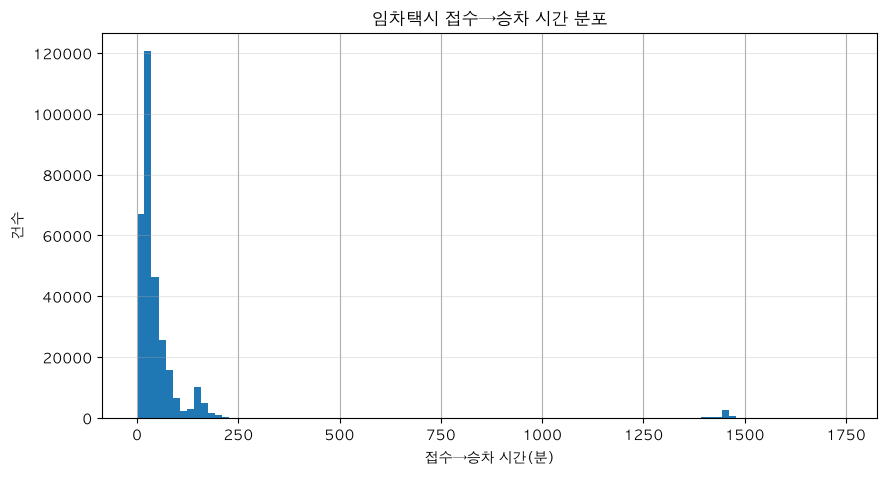

In [131]:
plt.figure(figsize=(10, 5))

df_rental["접수_승차_분"].dropna().hist(bins=100)

plt.title("임차택시 접수→승차 시간 분포")
plt.xlabel("접수→승차 시간(분)")
plt.ylabel("건수")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [132]:
# 접수-승차 날짜 차이 생성
df_rental["접수승차_날짜차이"] = (
    df_rental["승차일시"].dt.normalize()
    - df_rental["접수일시"].dt.normalize()
).dt.days

In [133]:
# 날짜 차이 분포 확인
receipt_boarding_date_diff_summary = (
    df_rental["접수승차_날짜차이"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

receipt_boarding_date_diff_summary.columns = [
    "접수승차_날짜차이",
    "건수",
]

display(receipt_boarding_date_diff_summary)

,접수승차_날짜차이,건수
0,0.0,305756
1,1.0,6841
2,NaN,16278


In [134]:
# 날짜 차이별 예약 목적 여부 확인
date_diff_reservation_summary = (
    df_rental
    .groupby(["접수승차_날짜차이", "예약목적여부"], dropna=False)
    .size()
    .reset_index(name="건수")
    .sort_values(["접수승차_날짜차이", "예약목적여부"])
)

display(date_diff_reservation_summary)

,접수승차_날짜차이,예약목적여부,건수
0,0.0,False,305743
1,0.0,True,13
2,1.0,False,10
3,1.0,True,6831
4,NaN,False,16183
5,NaN,True,95


In [135]:
# 자정 넘긴 바로콜 후보 확인
midnight_crossing_normal_candidates = df_rental[
    df_rental["접수승차_날짜차이"].eq(1)
    & ~df_rental["예약목적여부"]
    & df_rental["접수_승차_분"].between(0, 250, inclusive="both")
].copy()

print(
    "자정을 넘겼지만 접수→승차 시간이 180분 이하인 바로콜 후보:",
    f"{len(midnight_crossing_normal_candidates):,}건"
)

display(
    midnight_crossing_normal_candidates[
        [
            "접수일시",
            "승차일시",
            "접수_승차_분",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ].head(20)
)

자정을 넘겼지만 접수→승차 시간이 180분 이하인 바로콜 후보: 0건


,접수일시,승차일시,접수_승차_분,이용목적,출발구,출발동,목적구,목적동


#### 전일접수·예약성·장시간 후보 확인

전일접수, 예약 목적, 장시간 대기 후보는 바로콜 정상 대기시간을 왜곡할 수 있으므로 별도로 확인한다. 이 건들은 원자료에서 삭제하지 않고 예외 분석 대상으로 분리한다.

In [136]:
prev_day_or_long_wait_candidate = df_rental[
    df_rental["승차일시"].notna()
    & df_rental["접수일시"].notna()
    & (
        df_rental["접수승차_날짜차이"].gt(0)
        | df_rental["접수_승차_분"].gt(250)
        | df_rental["예약목적여부"]
    )
].copy()

print(f"전일접수/예약성/장시간 후보 건수: {len(prev_day_or_long_wait_candidate):,}건")

display(
    prev_day_or_long_wait_candidate[
        [
            "차량구분",
            "이용목적",
            "접수일시",
            "예정일시",
            "배차일시",
            "승차일시",
            "하차일시",
            "접수승차_날짜차이",
            "접수_승차_분",
            "예약목적여부",
            "출발구",
            "목적구"
        ]
    ]
    .sort_values(["접수승차_날짜차이", "접수_승차_분"], ascending=[False, False])
    .head(10)
)       

전일접수/예약성/장시간 후보 건수: 6,868건


,차량구분,이용목적,접수일시,예정일시,배차일시,승차일시,하차일시,접수승차_날짜차이,접수_승차_분,예약목적여부,출발구,목적구
697622,임차택시,예약광역,2025-06-03 07:17:38.000,2025-06-04 12:01:00,2025-06-04 12:02:06.810,2025-06-04 12:17:34.580,2025-06-04 13:12:34.473,1.0,1739.943000,True,은평구,계양구
638406,임차택시,예약광역,2025-05-21 07:05:53.000,2025-05-22 12:01:00,2025-05-22 11:58:18.100,2025-05-22 12:04:21.320,2025-05-22 12:47:05.393,1.0,1738.472000,True,노원구,포천시
1536388,임차택시,치료,2025-11-23 07:00:00.530,2025-11-24 10:30:00,2025-11-24 10:32:57.937,2025-11-24 10:47:13.360,2025-11-24 11:07:11.063,1.0,1667.213833,False,은평구,고양시덕양구
71752,임차택시,예약통학/출근,2025-01-16 07:02:23.000,2025-01-17 10:01:00,2025-01-17 10:04:16.707,2025-01-17 10:36:44.580,2025-01-17 11:20:14.050,1.0,1654.359667,True,강남구,용인시수지구
544594,임차택시,예약기타,2025-04-30 07:03:51.000,2025-05-01 10:01:00,2025-05-01 10:09:06.193,2025-05-01 10:25:24.627,2025-05-01 11:16:02.817,1.0,1641.560450,True,동작구,의왕시
1676924,임차택시,예약귀가,2025-12-21 07:09:11.000,2025-12-22 10:01:00,2025-12-22 10:07:31.333,2025-12-22 10:20:13.673,2025-12-22 10:55:24.220,1.0,1631.044550,True,강서구,계양구
1367247,임차택시,예약통학/출근,2025-10-20 08:03:28.000,2025-10-21 10:00:00,2025-10-21 10:10:15.253,2025-10-21 10:31:58.283,2025-10-21 11:16:33.267,1.0,1588.504717,True,은평구,동작구
967333,임차택시,예약기타,2025-07-28 08:00:42.000,2025-07-29 10:00:00,2025-07-29 10:02:01.817,2025-07-29 10:17:32.607,2025-07-29 10:43:21.610,1.0,1576.843450,True,서대문구,마포구
1589232,임차택시,예약재활,2025-12-03 09:05:16.000,2025-12-04 10:00:00,2025-12-04 10:04:12.473,2025-12-04 10:22:01.047,2025-12-04 10:46:14.187,1.0,1516.750783,True,중랑구,노원구
1507262,임차택시,예약기타,2025-11-17 10:02:53.000,2025-11-18 10:00:00,2025-11-18 11:02:00.443,2025-11-18 11:17:42.767,2025-11-18 12:35:15.600,1.0,1514.829450,True,구로구,강남구


### 7. 임차택시 바로콜 및 예외 여부 생성

임차택시 바로콜 건은 예약 목적이 아니고, `접수→승차` 시간이 바로콜로 해석 가능한 범위 안에 있는 건으로 정의한다.

예약 목적이 아닌 임차택시의 `접수→승차` 시간은 대부분 180분 이하에 분포하지만, 180~250분 구간도 2,387건 존재한다. 이 구간은 250분 이하 전체 분석 대상의 약 0.8%로 비중이 작고 실제 장시간 바로콜 가능성이 있으므로 별도 제외하지 않고 바로콜 분석 대상에 포함한다.

따라서 본 분석에서는 예약 목적이 아니면서 `접수→승차` 시간이 250분 이하인 건을 임차택시 바로콜로 통합한다.

전처리 기준:

| 구간 | 해석 | 처리 |
|---|---|---|
| 0~250분 | 바로콜 대기시간 범위 | 본 분석 포함 |
| 250분 초과 | 예약성/전일접수 또는 장시간 예외 가능성 높음 | 본 분석 제외, 예외 분석 보관 |

본 분석에서는 예약 목적이 아니고 `접수→승차` 시간이 250분 이하인 건을 임차택시 바로콜 건으로 사용한다.

기준 근거:

- 예약 목적이 아닌 임차택시의 `접수→승차` 시간 99분위수: 174.8분
- 180~250분 구간: 2,387건으로 250분 이하 전체 분석 대상의 약 0.8%
- 바로콜 본 분석 기준: 250분 이하
- 250분 초과 건: 24건으로 매우 적고 값의 편차가 커 예외 가능성이 높음
- 평균은 긴 대기 일부에 영향을 받으므로 제외 기준으로 사용하지 않음

In [137]:
df_rental["임차택시_바로콜여부"] = (
    ~df_rental["예약목적여부"]
    & df_rental["접수_승차_분"].between(0, 250, inclusive="both")
)

df_rental["임차택시_장시간예외여부"] = (
    ~df_rental["예약목적여부"]
    & df_rental["승차일시"].notna()
    & df_rental["접수_승차_분"].gt(250)
)

### 8. 임차택시 예외 여부 생성

바로콜 대기시간을 왜곡할 수 있는 건을 예외로 분리한다.

예외 건은 바로콜 본 분석에서는 제외하지만, 원자료에서 삭제하지 않고 별도 예외 분석 데이터셋에 보관한다.

예외 기준은 다음과 같다.

- `이용목적`에 `예약`이 포함된 건
- 예약 목적은 아니지만 `접수_승차_분`이 250분을 초과하는 건

현재 확인된 주요 예외는 다음과 같다.

- 예약 목적이지만 접수일자와 승차일자가 같은 건: 13건
- 예약 목적은 아니지만 접수일자보다 승차일자가 하루 뒤인 건: 10건
- 예약 목적이 아니고 `접수_승차_분 > 250`인 장시간 예외 후보: 24건

추가 확인 대상:

- 예약 목적이지만 접수일자와 승차일자가 같은 13건
- 예약 목적은 아니지만 접수일자보다 승차일자가 하루 뒤인 10건
- `접수_승차_분 > 250` 장시간 예외 후보 건수와 원자료
- `접수_승차_분` 최대값 부근의 원자료

In [140]:
# 임차택시 예외 여부 생성
df_rental["임차택시_예약성예외여부"] = (
    df_rental["예약목적여부"]
    | df_rental["임차택시_장시간예외여부"]
)

In [141]:
# 예외 유형별 건수 확인
exception_summary = pd.DataFrame({
    "예외유형": [
        "예약 목적 포함",
        "예약 목적 아님 + 접수→승차 250분 초과",
        "전체 예외",
    ],
    "건수": [
        df_rental["예약목적여부"].sum(),
        df_rental["임차택시_장시간예외여부"].sum(),
        df_rental["임차택시_예약성예외여부"].sum(),
    ],
})

display(exception_summary)

,예외유형,건수
0,예약 목적 포함,6939
1,예약 목적 아님 + 접수→승차 250분 초과,24
2,전체 예외,6963


In [142]:
# 예약 목적이지만 접수일자와 승차일자가 같은 13건 확인
reservation_same_day_cases = df_rental[
    df_rental["예약목적여부"]
    & df_rental["접수승차_날짜차이"].eq(0)
].copy()

print(
    "예약 목적이지만 접수일자와 승차일자가 같은 건수:",
    f"{len(reservation_same_day_cases):,}건"
)

display(
    reservation_same_day_cases[
        [
            "접수일시",
            "승차일시",
            "접수승차_날짜차이",
            "접수_승차_분",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ].head(20)
)

예약 목적이지만 접수일자와 승차일자가 같은 건수: 13건


,접수일시,승차일시,접수승차_날짜차이,접수_승차_분,이용목적,출발구,출발동,목적구,목적동
440235,2025-04-10 07:11:41.000,2025-04-10 07:37:26.180,0.0,25.753000,예약치료,양천구,목2동,서대문구,북아현동
446695,2025-04-11 08:01:46.000,2025-04-11 08:56:39.613,0.0,54.893550,예약기타,용산구,용산2가동,영등포구,여의동
475871,2025-04-17 10:03:20.000,2025-04-17 10:28:17.210,0.0,24.953500,예약치료,송파구,마천2동,강동구,길동
517267,2025-04-25 10:03:33.000,2025-04-25 10:36:48.680,0.0,33.261333,예약치료,영등포구,양평제2동,영등포구,영등포동
715292,2025-06-09 10:02:08.000,2025-06-09 10:31:39.640,0.0,29.527333,예약기타,관악구,은천동,관악구,신림동
832449,2025-07-02 11:08:06.000,2025-07-02 11:22:10.297,0.0,14.071617,예약기타,강남구,수서동,강남구,일원본동
832451,2025-07-02 11:08:24.000,2025-07-02 11:23:35.657,0.0,15.194283,예약기타,강남구,역삼1동,강남구,일원2동
946872,2025-07-23 14:44:36.733,2025-07-23 15:06:47.297,0.0,22.176067,예약기타,강동구,상일동,송파구,거여1동
1242818,2025-09-22 16:32:29.000,2025-09-22 18:03:45.497,0.0,91.274950,예약치료,금천구,독산제1동,금천구,독산제1동
1314650,2025-10-10 11:23:44.000,2025-10-10 11:56:40.690,0.0,32.944833,예약기타,용산구,서빙고동,성북구,동선동


In [143]:
# 예약 목적은 아니지만 접수일자보다 승차일자가 하루 뒤인 10건 확인
non_reservation_next_day_cases = df_rental[
    ~df_rental["예약목적여부"]
    & df_rental["접수승차_날짜차이"].eq(1)
].copy()

print(
    "예약 목적은 아니지만 접수일자보다 승차일자가 하루 뒤인 건수:",
    f"{len(non_reservation_next_day_cases):,}건"
)

display(
    non_reservation_next_day_cases[
        [
            "접수일시",
            "승차일시",
            "접수승차_날짜차이",
            "접수_승차_분",
            "임차택시_바로콜여부",
            "임차택시_장시간예외여부",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ].head(20)
)

예약 목적은 아니지만 접수일자보다 승차일자가 하루 뒤인 건수: 10건


,접수일시,승차일시,접수승차_날짜차이,접수_승차_분,임차택시_바로콜여부,임차택시_장시간예외여부,이용목적,출발구,출발동,목적구,목적동
86924,2025-01-20 11:07:49.000,2025-01-21 10:16:04.613,1.0,1388.260217,False,True,재활,노원구,공릉1.3동,노원구,상계6.7동
205697,2025-02-18 07:06:44.000,2025-02-19 07:17:43.353,1.0,1450.989217,False,True,기타,강동구,암사제3동,강동구,상일동
225257,2025-02-22 10:00:09.333,2025-02-23 10:25:37.917,1.0,1465.476400,False,True,기타,금천구,시흥제1동,구로구,구로제3동
434194,2025-04-08 07:07:24.000,2025-04-09 07:29:19.770,1.0,1461.929500,False,True,치료광역,금천구,시흥제5동,부평구,일신동
896386,2025-07-14 13:49:57.000,2025-07-15 10:14:20.167,1.0,1224.386117,False,True,기타,강서구,가양제2동,구로구,가리봉동
1041969,2025-08-12 12:17:44.000,2025-08-13 10:12:52.830,1.0,1315.147167,False,True,기타,강서구,가양제1동,강서구,우장산동
1385822,2025-10-23 10:00:19.000,2025-10-24 10:14:05.790,1.0,1453.779833,False,True,기타,양천구,신정3동,양천구,목5동
1536388,2025-11-23 07:00:00.530,2025-11-24 10:47:13.360,1.0,1667.213833,False,True,치료,은평구,수색동,고양시덕양구,행신1동
1652722,2025-12-16 08:00:03.337,2025-12-17 08:31:37.207,1.0,1471.564500,False,True,기타,강북구,삼각산동,성북구,삼선동
1683051,2025-12-22 11:07:28.000,2025-12-23 10:20:53.573,1.0,1393.426217,False,True,치료,동대문구,신설동,동대문구,회기동


In [144]:
# 장시간 예외 후보 원자료 확인
long_wait_exception_cases = df_rental[
    df_rental["임차택시_장시간예외여부"]
].copy()

print(
    "예약 목적이 아니고 접수→승차 250분 초과인 장시간 예외 후보:",
    f"{len(long_wait_exception_cases):,}건"
)

display(
    long_wait_exception_cases[
        [
            "접수일시",
            "배차일시",
            "승차일시",
            "접수_배차_분",
            "접수_승차_분",
            "배차_승차_분",
            "접수승차_날짜차이",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ].sort_values("접수_승차_분", ascending=False)
)

예약 목적이 아니고 접수→승차 250분 초과인 장시간 예외 후보: 24건


,접수일시,배차일시,승차일시,접수_배차_분,접수_승차_분,배차_승차_분,접수승차_날짜차이,이용목적,출발구,출발동,목적구,목적동
1536388,2025-11-23 07:00:00.530,2025-11-24 10:32:57.937,2025-11-24 10:47:13.360,1652.956783,1667.213833,14.257050,1.0,치료,은평구,수색동,고양시덕양구,행신1동
1652722,2025-12-16 08:00:03.337,2025-12-17 08:06:09.120,2025-12-17 08:31:37.207,1446.096383,1471.564500,25.468117,1.0,기타,강북구,삼각산동,성북구,삼선동
225257,2025-02-22 10:00:09.333,2025-02-23 10:01:51.927,2025-02-23 10:25:37.917,1441.709900,1465.476400,23.766500,1.0,기타,금천구,시흥제1동,구로구,구로제3동
434194,2025-04-08 07:07:24.000,2025-04-09 07:16:49.460,2025-04-09 07:29:19.770,1449.424333,1461.929500,12.505167,1.0,치료광역,금천구,시흥제5동,부평구,일신동
1385822,2025-10-23 10:00:19.000,2025-10-24 10:01:46.593,2025-10-24 10:14:05.790,1441.459883,1453.779833,12.319950,1.0,기타,양천구,신정3동,양천구,목5동
205697,2025-02-18 07:06:44.000,2025-02-19 07:07:07.013,2025-02-19 07:17:43.353,1440.383550,1450.989217,10.605667,1.0,기타,강동구,암사제3동,강동구,상일동
1683051,2025-12-22 11:07:28.000,2025-12-23 10:01:34.693,2025-12-23 10:20:53.573,1374.111550,1393.426217,19.314667,1.0,치료,동대문구,신설동,동대문구,회기동
86924,2025-01-20 11:07:49.000,2025-01-21 10:02:39.607,2025-01-21 10:16:04.613,1374.843450,1388.260217,13.416767,1.0,재활,노원구,공릉1.3동,노원구,상계6.7동
1041969,2025-08-12 12:17:44.000,2025-08-13 10:03:34.480,2025-08-13 10:12:52.830,1305.841333,1315.147167,9.305833,1.0,기타,강서구,가양제1동,강서구,우장산동
896386,2025-07-14 13:49:57.000,2025-07-15 10:07:26.257,2025-07-15 10:14:20.167,1217.487617,1224.386117,6.898500,1.0,기타,강서구,가양제2동,구로구,가리봉동


임차택시 예외는 `이용목적`에 `예약`이 포함된 건과, 예약 목적은 아니지만 `접수→승차` 시간이 250분을 초과하는 건으로 정의한다. 접수일자와 승차일자의 날짜 차이는 전일접수 형태를 확인하기 위한 보조 지표로만 사용하며, 날짜가 다르다는 이유만으로 예외로 분류하지 않는다.

### 9. 취소 분석 유형 생성

취소 건은 `승차일시`가 없을 수 있으므로 `접수_승차_분`으로 바로콜 여부를 판단하기 어렵다. 따라서 취소 분석에서는 우선 `이용목적` 기준으로 바로콜 취소와 예약성 예외 취소를 나눈다.

취소 분석 유형은 다음과 같이 정의한다.

| 취소 분석 유형 | 기준 | 해석 |
|---|---|---|
| 바로콜 취소 | `취소일시` 있음 + 예약 목적 아님 | 바로콜 접수 후 취소된 건 |
| 예약성 예외 취소 | `취소일시` 있음 + 예약 목적 포함 | 예약성 접수 후 취소된 예외 건 |

확인할 내용:

- 바로콜 취소 건수
- 예약성 예외 취소 건수
- 취소 건의 `접수_취소_분` 분포
- 배차 후 취소 건의 `배차_취소_분` 분포
- 장시간 취소 건의 이용목적 분포

주의사항:

- 취소 건은 `승차일시`가 없을 수 있으므로 `접수_승차_분` 기준을 적용하지 않는다.
- 취소 분석에서는 `접수→취소`와 `배차→취소`를 함께 확인한다.
- 배차일시가 없는 취소 건은 `배차→취소`를 계산할 수 없으므로 배차 전 취소 또는 배차일시 미기록 취소로 별도 확인한다.

In [145]:
# 취소 분석 유형 생성
df_rental["임차택시_취소분석유형"] = pd.NA

df_rental.loc[
    df_rental["취소일시"].notna() & ~df_rental["예약목적여부"],
    "임차택시_취소분석유형"
] = "바로콜 취소"

df_rental.loc[
    df_rental["취소일시"].notna() & df_rental["예약목적여부"],
    "임차택시_취소분석유형"
] = "예약성 예외 취소"

In [146]:
# 취소 분석 유형별 건수 확인
rental_cancel_type_summary = (
    df_rental["임차택시_취소분석유형"]
    .value_counts(dropna=False)
    .reset_index()
)

rental_cancel_type_summary.columns = [
    "임차택시_취소분석유형",
    "건수",
]

display(rental_cancel_type_summary)

,임차택시_취소분석유형,건수
0,NaN,312597
1,바로콜 취소,16183
2,예약성 예외 취소,95


In [147]:
# 취소 건만 분리
rental_cancel = df_rental[
    df_rental["취소일시"].notna()
].copy()

rental_cancel_normal = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "바로콜 취소")
].copy()

rental_cancel_exception = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "예약성 예외 취소")
].copy()

print(f"임차택시 취소 전체: {len(rental_cancel):,}건")
print(f"바로콜 취소: {len(rental_cancel_normal):,}건")
print(f"예약성 예외 취소: {len(rental_cancel_exception):,}건")

임차택시 취소 전체: 16,278건
바로콜 취소: 16,183건
예약성 예외 취소: 95건


In [148]:
# 배차 전/후 취소 건수 확인
cancel_dispatch_summary = pd.DataFrame({
    "구분": [
        "취소 전체",
        "배차 후 취소",
        "배차 전 취소 또는 배차일시 미기록 취소",
    ],
    "건수": [
        df_rental["취소일시"].notna().sum(),
        (
            df_rental["취소일시"].notna()
            & df_rental["배차일시"].notna()
        ).sum(),
        (
            df_rental["취소일시"].notna()
            & df_rental["배차일시"].isna()
        ).sum(),
    ],
})

display(cancel_dispatch_summary)

,구분,건수
0,취소 전체,16278
1,배차 후 취소,16262
2,배차 전 취소 또는 배차일시 미기록 취소,16


In [149]:
# 취소 대기시간 요약
cancel_wait_summary = []

for group_name, group_df in {
    "취소 전체": rental_cancel,
    "바로콜 취소": rental_cancel_normal,
    "예약성 예외 취소": rental_cancel_exception,
}.items():
    cancel_wait_summary.append({
        "구분": group_name,
        "건수": len(group_df),
        "접수→취소 평균": group_df["접수_취소_분"].mean(),
        "접수→취소 중앙값": group_df["접수_취소_분"].median(),
        "접수→취소 75분위수": group_df["접수_취소_분"].quantile(0.75),
        "접수→취소 90분위수": group_df["접수_취소_분"].quantile(0.90),
        "배차→취소 평균": group_df["배차_취소_분"].mean(),
        "배차→취소 중앙값": group_df["배차_취소_분"].median(),
        "배차→취소 75분위수": group_df["배차_취소_분"].quantile(0.75),
        "배차→취소 90분위수": group_df["배차_취소_분"].quantile(0.90),
    })

cancel_wait_summary = pd.DataFrame(cancel_wait_summary)

display(cancel_wait_summary)

,구분,건수,접수→취소 평균,접수→취소 중앙값,접수→취소 75분위수,접수→취소 90분위수,배차→취소 평균,배차→취소 중앙값,배차→취소 75분위수,배차→취소 90분위수
0,취소 전체,16278,42.499638,16.750000,42.903500,129.138282,5.079621,2.702775,5.390237,12.131872
1,바로콜 취소,16183,35.345558,16.583333,42.281558,128.367767,5.070226,2.698950,5.381083,12.090047
2,예약성 예외 취소,95,1261.178359,1405.550000,1444.956417,1450.051867,6.678539,4.168550,7.870975,16.233520


### 10. 분석 포함 여부 및 제외 사유 생성

최종 분석에 포함되는 건과 제외되는 건을 명시적으로 표시한다.

승차 대기시간 분석은 `임차택시_바로콜여부`를 기준으로 포함 여부를 판단한다. 즉, 예약 목적이 아니고 `접수→승차` 시간이 250분 이하인 건을 본 분석에 포함한다.

제외 사유는 다음과 같이 구분한다.

| 제외 사유 | 기준 | 해석 |
|---|---|---|
| 예약 목적 포함 | `이용목적`에 `예약` 포함 | 임차택시는 바로콜만 가능한 것으로 확인되었으므로 예약성 예외로 분리 |
| 접수→승차 250분 초과 | 예약 목적 아님 + `접수_승차_분 > 250` | 장시간 예외 또는 기록 예외 가능성이 높아 본 분석 제외 |
| 시간 순서 이상 | 대기시간 음수 | 정상 대기시간으로 해석 불가 |

주의사항:

- 취소 분석은 별도 분석 대상이므로 `승차일시`가 없다는 이유만으로 제거하지 않는다.
- 승차 대기시간 분석과 취소 대기시간 분석의 포함 기준을 구분한다.
- 취소 분석에서는 `임차택시_취소분석유형`을 기준으로 바로콜 취소와 예약성 예외 취소를 구분한다.

In [150]:
# 분석 포함 여부 및 제외 사유 생성
df_rental["대기시간분석_포함여부"] = df_rental["임차택시_바로콜여부"]
df_rental["대기시간분석_제외사유"] = pd.NA

df_rental.loc[
    df_rental["예약목적여부"],
    "대기시간분석_제외사유"
] = "예약 목적 포함"

df_rental.loc[
    df_rental["임차택시_장시간예외여부"],
    "대기시간분석_제외사유"
] = "접수→승차 250분 초과"

df_rental.loc[
    df_rental["접수_승차_분"] < 0,
    "대기시간분석_제외사유"
] = "시간 순서 이상"

In [151]:
# 포함 여부별 건수 확인
analysis_include_summary = (
    df_rental["대기시간분석_포함여부"]
    .value_counts(dropna=False)
    .reset_index()
)

analysis_include_summary.columns = [
    "대기시간분석_포함여부",
    "건수",
]

display(analysis_include_summary)

,대기시간분석_포함여부,건수
0,True,305729
1,False,23146


In [155]:
# 제외 사유별 건수 확인
analysis_exclusion_summary = (
    df_rental["대기시간분석_제외사유"]
    .fillna("제외 사유 없음")
    .value_counts()
    .reset_index()
)

analysis_exclusion_summary.columns = [
    "대기시간분석_제외사유",
    "건수",
]

display(analysis_exclusion_summary)

,대기시간분석_제외사유,건수
0,제외 사유 없음,321912
1,예약 목적 포함,6939
2,접수→승차 250분 초과,24


In [154]:
# 제외 대상 원자료 확인
excluded_rental_cases = df_rental[
    ~df_rental["대기시간분석_포함여부"]
    & df_rental["승차일시"].notna()
].copy()

print(f"승차 대기시간 본 분석 제외 건수: {len(excluded_rental_cases):,}건")

display(
    excluded_rental_cases[
        [
            "대기시간분석_제외사유",
            "접수일시",
            "배차일시",
            "승차일시",
            "접수_배차_분",
            "접수_승차_분",
            "배차_승차_분",
            "접수승차_날짜차이",
            "이용목적",
            "출발구",
            "출발동",
            "목적구",
            "목적동",
        ]
    ]
    .sort_values(["대기시간분석_제외사유", "접수_승차_분"], ascending=[True, False])
    .head(10)
)

승차 대기시간 본 분석 제외 건수: 6,868건


,대기시간분석_제외사유,접수일시,배차일시,승차일시,접수_배차_분,접수_승차_분,배차_승차_분,접수승차_날짜차이,이용목적,출발구,출발동,목적구,목적동
697622,예약 목적 포함,2025-06-03 07:17:38,2025-06-04 12:02:06.810,2025-06-04 12:17:34.580,1724.480167,1739.943000,15.462833,1.0,예약광역,은평구,응암제2동,계양구,계산2동
638406,예약 목적 포함,2025-05-21 07:05:53,2025-05-22 11:58:18.100,2025-05-22 12:04:21.320,1732.418333,1738.472000,6.053667,1.0,예약광역,노원구,하계1동,포천시,포천동
71752,예약 목적 포함,2025-01-16 07:02:23,2025-01-17 10:04:16.707,2025-01-17 10:36:44.580,1621.895117,1654.359667,32.464550,1.0,예약통학/출근,강남구,일원본동,용인시수지구,성복동
544594,예약 목적 포함,2025-04-30 07:03:51,2025-05-01 10:09:06.193,2025-05-01 10:25:24.627,1625.253217,1641.560450,16.307233,1.0,예약기타,동작구,신대방제2동,의왕시,고천동
1676924,예약 목적 포함,2025-12-21 07:09:11,2025-12-22 10:07:31.333,2025-12-22 10:20:13.673,1618.338883,1631.044550,12.705667,1.0,예약귀가,강서구,등촌제3동,계양구,계산3동
1367247,예약 목적 포함,2025-10-20 08:03:28,2025-10-21 10:10:15.253,2025-10-21 10:31:58.283,1566.787550,1588.504717,21.717167,1.0,예약통학/출근,은평구,구산동,동작구,흑석동
967333,예약 목적 포함,2025-07-28 08:00:42,2025-07-29 10:02:01.817,2025-07-29 10:17:32.607,1561.330283,1576.843450,15.513167,1.0,예약기타,서대문구,북가좌제2동,마포구,도화동
1589232,예약 목적 포함,2025-12-03 09:05:16,2025-12-04 10:04:12.473,2025-12-04 10:22:01.047,1498.941217,1516.750783,17.809567,1.0,예약재활,중랑구,망우본동,노원구,상계6.7동
1507262,예약 목적 포함,2025-11-17 10:02:53,2025-11-18 11:02:00.443,2025-11-18 11:17:42.767,1499.124050,1514.829450,15.705400,1.0,예약기타,구로구,수궁동,강남구,수서동
1559741,예약 목적 포함,2025-11-27 08:02:53,2025-11-28 08:32:55.497,2025-11-28 09:04:51.690,1470.041617,1501.978167,31.936550,1.0,예약기타,강서구,가양제1동,강서구,가양제1동


### 11. 분석용 데이터셋 분리

전처리 후 분석 목적에 따라 데이터셋을 나눈다.

승차 대기시간 분석과 취소 대기시간 분석은 기준 컬럼이 다르므로 데이터셋을 분리해서 사용한다.

| 데이터셋 | 필요 여부 | 이유 |
|---|---|---|
| `df_rental` | 필요 | 전체 전처리 결과, 검증·건수 확인용 |
| `rental_ride_normal` | 필요 | 바로콜 승차 대기시간 본 분석 |
| `rental_ride_exception` | 필요 | 예약 목적/250분 초과 예외 건수 확인용 |
| `rental_cancel` | 선택 | 취소 전체 규모 확인용 |
| `rental_cancel_normal` | 필요 | 바로콜 취소 대기시간 본 분석 |
| `rental_cancel_exception` | 선택 | 예약성 예외 취소 95건 확인용 |

분석 기준:

- 승차 대기시간 본 분석은 `rental_ride_normal`을 사용한다.
- 승차 예외 확인은 `rental_ride_exception`을 사용한다.
- 취소 대기시간 본 분석은 `rental_cancel_normal`을 사용한다.
- 예약성 예외 취소는 본 분석에서 제외하고, `rental_cancel_exception`으로 건수만 확인한다.

In [156]:
rental_ride_normal = df_rental[
    df_rental["승차일시"].notna()
    & df_rental["임차택시_바로콜여부"]
].copy()

rental_ride_exception = df_rental[
    df_rental["승차일시"].notna()
    & df_rental["임차택시_예약성예외여부"]
].copy()

rental_cancel = df_rental[
    df_rental["취소일시"].notna()
].copy()

rental_cancel_normal = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "바로콜 취소")
].copy()

rental_cancel_exception = df_rental[
    df_rental["취소일시"].notna()
    & (df_rental["임차택시_취소분석유형"] == "예약성 예외 취소")
].copy()

In [157]:
print("임차택시 전체:", len(df_rental))
print("서울 외→서울 외 제외 후 임차택시:", len(df_rental))
print("바로콜 승차(250분 이하):", len(rental_ride_normal))
print("예약성/장시간 예외 승차:", len(rental_ride_exception))
print("취소 전체:", len(rental_cancel))
print("바로콜 취소:", len(rental_cancel_normal))
print("예약성 예외 취소:", len(rental_cancel_exception))

임차택시 전체: 328875
서울 외→서울 외 제외 후 임차택시: 328875
바로콜 승차(250분 이하): 305729
예약성/장시간 예외 승차: 6868
취소 전체: 16278
바로콜 취소: 16183
예약성 예외 취소: 95


## 전처리 데이터 저장

임차택시 대기시간 데이터를 전처리한 후 CSV 파일로 저장합니다.

In [158]:
processed_dir = PROJECT_ROOT / "data" / "processed"

rental_wait_preprocessed_path = (
    processed_dir / "임차택시_대기시간_전처리.csv"
)

df_rental.to_csv(
    rental_wait_preprocessed_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"저장 완료: {rental_wait_preprocessed_path}")
print(f"저장 건수: {len(df_rental):,}건")

저장 완료: /Users/blaumonde/calltaxi-DA/data/processed/임차택시_대기시간_전처리.csv
저장 건수: 328,875건
